In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential 
from tensorflow.keras.layers import Dense

In [5]:
df = pd.read_csv('1_boston_housing.csv')
print('Dataset Shape:',df.shape)
df.head(10)

Dataset Shape: (506, 14)


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2
5,0.02985,0.0,2.18,0,0.458,6.430,58.7,6.0622,3,222,18.7,394.12,5.21,28.7
6,0.08829,12.5,7.87,0,0.524,6.012,66.6,5.5605,5,311,15.2,395.60,12.43,22.9
7,0.14455,12.5,7.87,0,0.524,6.172,96.1,5.9505,5,311,15.2,396.90,19.15,27.1
8,0.21124,12.5,7.87,0,0.524,5.631,100.0,6.0821,5,311,15.2,386.63,29.93,16.5
9,0.17004,12.5,7.87,0,0.524,6.004,85.9,6.5921,5,311,15.2,386.71,17.10,18.9


In [7]:
X=df.drop('MEDV',axis=1)
y=df['MEDV']

print('Features shape:',X.shape)
print('Target shape:',y.shape)

Features shape: (506, 13)
Target shape: (506,)


In [9]:
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42
)
print('Training samples:',X_train.shape[0])
print('Testing samples:',X_test.shape[0])

Training samples: 404
Testing samples: 102


In [11]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

print('Scaling done.')

Scaling done.


In [13]:
model=Sequential()
model.add(Dense(64,activation='relu',input_shape=(X_train.shape[1],)))
model.add(Dense(32,activation='relu'))
model.add(Dense(16,activation='relu'))
model.add(Dense(1))
model.summary()

C:\Users\suyas\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,521 (13.75 KB)

 Trainable params: 3,521 (13.75 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [17]:
history=model.fit(
    X_train,y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.1,
    verbose=1
)

Epoch 1/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 604.5957 - mae: 22.5630 - val_loss: 565.5884 - val_mae: 22.1729
Epoch 2/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 543.9942 - mae: 21.3644 - val_loss: 490.4513 - val_mae: 20.3623
Epoch 3/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 452.3507 - mae: 18.7315 - val_loss: 315.6603 - val_mae: 15.8463
Epoch 4/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 273.1214 - mae: 13.6725 - val_loss: 76.5240 - val_mae: 7.0701
Epoch 5/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 67.3659 - mae: 6.5682 - val_loss: 40.9949 - val_mae: 3.9760
Epoch 6/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 35.9365 - mae: 4.5756 - val_loss: 38.2860 - val_mae: 4.0409
Epoch 7/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 25.4693 - mae: 3.8611 - val_loss: 38.6240 - val_mae: 4.1456
Epoch 8/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 27.8526 - mae: 3.8873 - val_loss: 36.1345 - val_mae: 4.0553
Epoch 9/100
23/23 ━━━━━━━━━━━━━━━

In [18]:
test_loss,test_mae=model.evaluate(X_test,y_test)
print("Mean squared error on test data :",round(test_loss,4))
print("Mean absolute error on test data :",round(test_mae,4))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 8.8734 - mae: 2.0990
Mean squared error on test data : 11.5781
Mean absolute error on test data : 2.2665


In [21]:
y_pred = model.predict(X_test).flatten()
for actual, predicted in zip(y_test[:5], y_pred[:5]):
  print(actual,predicted)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
23.6 27.015022
32.4 32.82771
13.6 15.940864
22.8 23.9296
16.1 15.285092


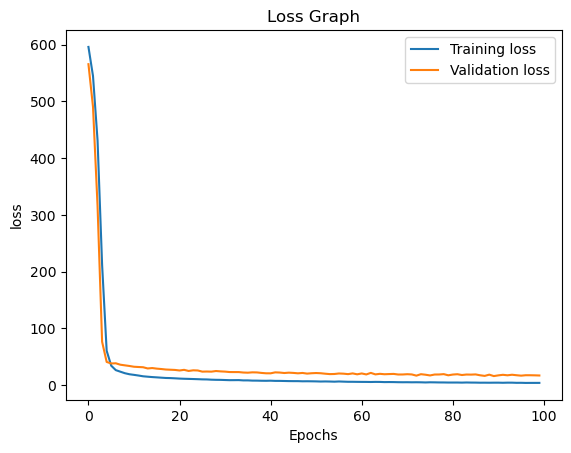

In [23]:
plt.plot(history.history['loss'], label = "Training loss")
plt.plot(history.history['val_loss'], label = "Validation loss")
plt.legend()
plt.title("Loss Graph")
plt.xlabel("Epochs")
plt.ylabel("loss")
plt.show()